In [1]:
pip install gensim

  Using cached gensim-4.4.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
Using cached gensim-4.4.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (27.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [16]:
import csv
import sys

csv.field_size_limit(sys.maxsize)

with open("../week06/Fixed_news_dataset.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    data = list(reader)

    # Lấy danh sách field names (tên cột)
    fieldnames = reader.fieldnames
    
    

In [17]:
print(f"Tổng số mẫu: {len(data)}")
# print(data[0])
# In ra tất cả các field
print("Các field trong CSV:")
for field in fieldnames:
    print(field)

Tổng số mẫu: 184539
Các field trong CSV:
Unnamed: 0.1
Unnamed: 0
id
author
content
picture_count
processed
source
title
topic
url
crawled_at


In [18]:
topics = []
for i in data:
    if i["topic"] not in topics:
        topics.append(i["topic"])
        print(i["topic"])

Pháp luật
Sức khỏe - Đời sống
Giáo dục
Thế giới
Thời sự
Văn hóa - Giải trí
Thể thao
Xã hội
Bất động sản
Công nghệ
Kinh tế
Kinh doanh - Tài chính
Bạn đọc
Chính trị
Quốc phòng
Xe
Pháp luật


In [19]:
economical_topics = {"Bất động sản", "Kinh tế", "Kinh doanh - Tài chính"}

for i in data:
    i["label"] = 1 if i["topic"] in economical_topics else 0

In [20]:
import random

random.seed(42)

data_label_1 = [i for i in data if i["label"] == 1]
data_label_0 = [i for i in data if i["label"] == 0]

sample_label_1 = random.sample(data_label_1, 3000)
sample_label_0 = random.sample(data_label_0, 17000)

sample_dataset = sample_label_1 + sample_label_0
random.shuffle(sample_dataset)

# Kiểm tra tỉ lệ
count_label_1 = sum(1 for i in sample_dataset if i["label"] == 1)
count_label_0 = sum(1 for i in sample_dataset if i["label"] == 0)
ratio_label_1 = count_label_1 / len(sample_dataset)
ratio_label_0 = count_label_0 / len(sample_dataset)

print(f"Tổng số mẫu: {len(sample_dataset)}")
print(f"Số mẫu label 1: {count_label_1} ({ratio_label_1:.2%})")
print(f"Số mẫu label 0: {count_label_0} ({ratio_label_0:.2%})")

Tổng số mẫu: 20000
Số mẫu label 1: 3000 (15.00%)
Số mẫu label 0: 17000 (85.00%)


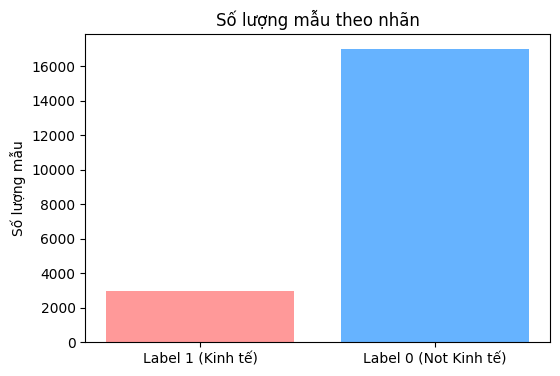

In [21]:
import matplotlib.pyplot as plt

# Dữ liệu cho biểu đồ
labels = ['Label 1 (Kinh tế)', 'Label 0 (Not Kinh tế)']
counts = [count_label_1, count_label_0]


# Biểu đồ cột
plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['#ff9999','#66b3ff'])
plt.ylabel('Số lượng mẫu')
plt.title('Số lượng mẫu theo nhãn')
plt.show()

In [22]:
vietnamese_stopwords = set([
    'bị', 'bởi', 'cả', 'các', 'cái', 'cần', 'càng', 'chỉ', 'chiếc',
    'cho', 'chứ', 'chưa', 'chuyện', 'có', 'có_thể', 'cứ', 'của', 'cùng',
    'cũng', 'đã', 'đang', 'đây', 'để', 'đến_nỗi', 'đều', 'điều', 'do',
    'đó', 'được', 'dưới', 'gì', 'khi', 'không', 'là', 'lại', 'lên', 'lúc',
    'mà', 'mỗi', 'một_cách', 'này', 'nên', 'nếu', 'ngay', 'nhiều', 'như',
    'nhưng', 'những', 'nơi', 'nữa', 'phải', 'qua', 'ra', 'rằng', 'rất',
    'rồi', 'sau', 'sẽ', 'so', 'sự', 'tại', 'theo', 'thì', 'trên', 'trước',
    'từ', 'từng', 'và', 'vẫn', 'vào', 'vậy', 'vì', 'việc', 'với', 'vừa'
])

In [23]:
import re
from underthesea import word_tokenize

def preprocess_texts_vn(texts, stopwords=None, lowercase=True, remove_punct=True, return_tokens=False):
    processed_texts = []
    
    for text in texts:
        # 1. Chuyển lowercase
        if lowercase:
            text = text.lower()
        
        # 2. Xóa ký tự đặc biệt, số, dấu câu
        if remove_punct:
            text = re.sub(r'[^\w\s]', ' ', text)  # loại bỏ punctuation
            text = re.sub(r'\d+', ' ', text)      # loại bỏ số
            text = re.sub(r'\s+', ' ', text)      # loại bỏ khoảng trắng thừa
            text = text.strip()
        
        # 3. Tokenize
        tokens = word_tokenize(text, format="text").split()
        
        # 4. Loại bỏ stopwords
        if stopwords:
            tokens = [t for t in tokens if t not in stopwords]
        
        # 5. Trả về token hoặc string
        if return_tokens:
            processed_texts.append(tokens)
        else:
            processed_texts.append(' '.join(tokens))
    
    return processed_texts


In [24]:
texts = [item["title"] for item in sample_dataset]
texts

# Tiền xử lý trả về chuỗi sạch
texts_clean = preprocess_texts_vn(texts, stopwords=vietnamese_stopwords)
texts_clean[0]

'niềm vui'

In [25]:
texts = texts_clean
label = [i["label"] for i in sample_dataset]

print(texts[8])
print(label[8])
print(len(texts))
print(len(label))

cử_tri đề_nghị công_khai công_trình_tốc châu_đốc thơ_sóc trăng
0
20000
20000


### Tokenize thành list từ

In [27]:
sentences = [text.split() for text in texts]
sentences[0]

['niềm', 'vui']

### Train Word2Vec

In [28]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # số chiều vector
    window=5,          # context window
    min_count=2,       # bỏ từ hiếm
    workers=4,
    sg=1               # 1 = Skip-gram, 0 = CBOW
)

### Hàm lấy vector trung bình

In [29]:
import numpy as np

def document_vector(model, tokens):
    vectors = []
    
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

In [33]:
X = np.array([document_vector(w2v_model, text.split()) for text in texts])
y = np.array(label)

In [31]:
X

array([[-0.12154599,  0.18845469, -0.10533197, ..., -0.25768429,
         0.05912836, -0.03300751],
       [-0.08350746,  0.07952408, -0.02363603, ..., -0.21982212,
        -0.02310952,  0.00085898],
       [-0.12962009,  0.08474651,  0.04245198, ..., -0.26964667,
         0.02732756, -0.01632254],
       ...,
       [-0.0939512 ,  0.1047321 , -0.05450223, ..., -0.24825928,
         0.00957919,  0.0962144 ],
       [-0.07867357,  0.0954576 , -0.08188757, ..., -0.31471765,
         0.07667156,  0.0674891 ],
       [-0.05912156,  0.23129776, -0.09485784, ..., -0.29874113,
         0.01500456, -0.05334093]], shape=(20000, 100))

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
def evaluate_and_print(model_name, vectorizer_name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    print(f"=== Model: {model_name} | Vectorizer: {vectorizer_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(report)
    print("\n")

=== Model: Logistic Regression | Vectorizer: Word2Vec ===
Accuracy : 0.8920
Precision: 0.7234
Recall   : 0.4533
F1-score : 0.5574
Confusion Matrix:
[[3296  104]
 [ 328  272]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      3400
           1       0.72      0.45      0.56       600

    accuracy                           0.89      4000
   macro avg       0.82      0.71      0.75      4000
weighted avg       0.88      0.89      0.88      4000





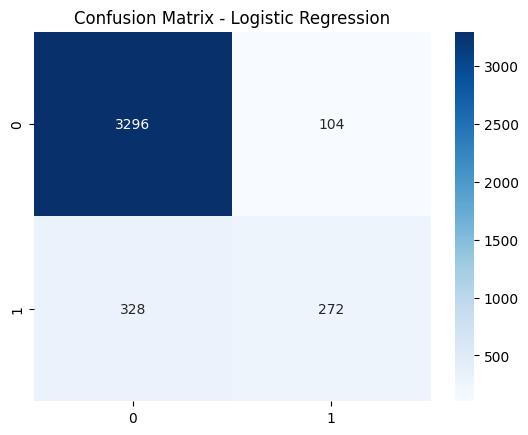

=== Model: SVM | Vectorizer: Word2Vec ===
Accuracy : 0.8902
Precision: 0.7588
Recall   : 0.3933
F1-score : 0.5181
Confusion Matrix:
[[3325   75]
 [ 364  236]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3400
           1       0.76      0.39      0.52       600

    accuracy                           0.89      4000
   macro avg       0.83      0.69      0.73      4000
weighted avg       0.88      0.89      0.88      4000





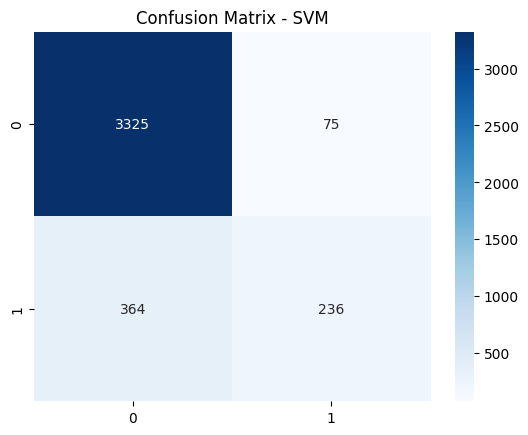

In [44]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ===================== Logistic Regression =====================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

evaluate_and_print("Logistic Regression", "Word2Vec", y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ===================== SVM =====================
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

evaluate_and_print("SVM", "Word2Vec", y_test, y_pred_svm)
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.show()

In [53]:
w2v_model2 = Word2Vec(
    sentences=sentences,
    vector_size=300,   # tăng số chiều vector từ 100 -> 300
    window=7,          # tăng window từ 5->7
    min_count=1,       # giảm từ hiếm từ 2->1
    workers=4,         # 
    sg=1,              # 0 = CBOW
    epochs=20          # thêm epoch
)

In [54]:
X = np.array([document_vector(w2v_model2, text.split()) for text in texts])
y = np.array(label)

=== Model: Logistic Regression | Vectorizer: Word2Vec ===
Accuracy : 0.9025
Precision: 0.7313
Recall   : 0.5533
F1-score : 0.6300
Confusion Matrix:
[[3278  122]
 [ 268  332]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3400
           1       0.73      0.55      0.63       600

    accuracy                           0.90      4000
   macro avg       0.83      0.76      0.79      4000
weighted avg       0.90      0.90      0.90      4000





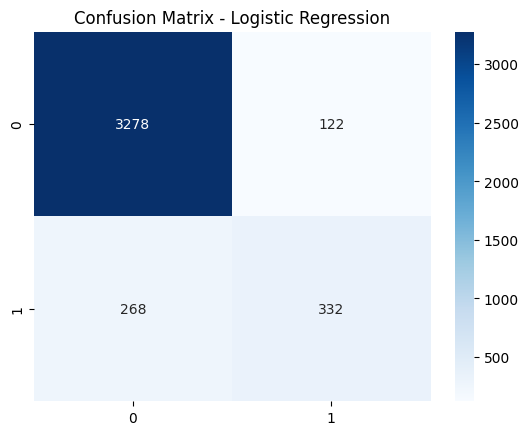

=== Model: SVM | Vectorizer: Word2Vec ===
Accuracy : 0.9052
Precision: 0.7663
Recall   : 0.5300
F1-score : 0.6266
Confusion Matrix:
[[3303   97]
 [ 282  318]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      3400
           1       0.77      0.53      0.63       600

    accuracy                           0.91      4000
   macro avg       0.84      0.75      0.79      4000
weighted avg       0.90      0.91      0.90      4000





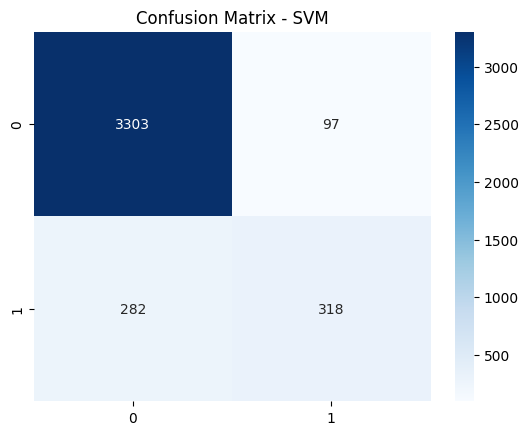

In [55]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ===================== Logistic Regression =====================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

evaluate_and_print("Logistic Regression", "Word2Vec", y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ===================== SVM =====================
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

evaluate_and_print("SVM", "Word2Vec", y_test, y_pred_svm)
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.show()

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf.fit(texts)

idf_dict = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

def document_vector_tfidf(model, tokens):
    vectors = []
    weights = []


    for word in tokens:
        if word in model.wv and word in idf_dict:
            vectors.append(model.wv[word])
            weights.append(idf_dict[word])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.average(vectors, axis=0, weights=weights)

In [64]:
w2v_model3 = Word2Vec(
    sentences=sentences,
    vector_size=300,   # tăng số chiều vector từ 100 -> 300
    window=7,          # tăng window từ 5->7
    min_count=1,       # giảm từ hiếm từ 2->1
    workers=4,         # 
    sg=1,              # skip-gramgram
    epochs=20          # thêm epoch
)

In [65]:
X = np.array([document_vector_tfidf(w2v_model3, text.split()) for text in texts])
y = np.array(label)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

=== Model: Logistic Regression | Vectorizer: Word2Vec ===
Accuracy : 0.9050
Precision: 0.7350
Recall   : 0.5733
F1-score : 0.6442
Confusion Matrix:
[[3276  124]
 [ 256  344]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      3400
           1       0.74      0.57      0.64       600

    accuracy                           0.91      4000
   macro avg       0.83      0.77      0.79      4000
weighted avg       0.90      0.91      0.90      4000





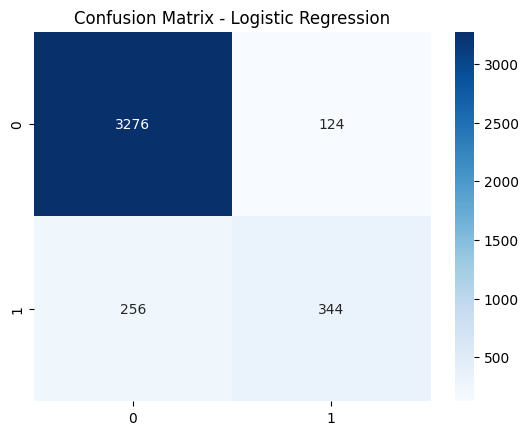

=== Model: SVM | Vectorizer: Word2Vec ===
Accuracy : 0.9048
Precision: 0.7461
Recall   : 0.5533
F1-score : 0.6354
Confusion Matrix:
[[3287  113]
 [ 268  332]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      3400
           1       0.75      0.55      0.64       600

    accuracy                           0.90      4000
   macro avg       0.84      0.76      0.79      4000
weighted avg       0.90      0.90      0.90      4000





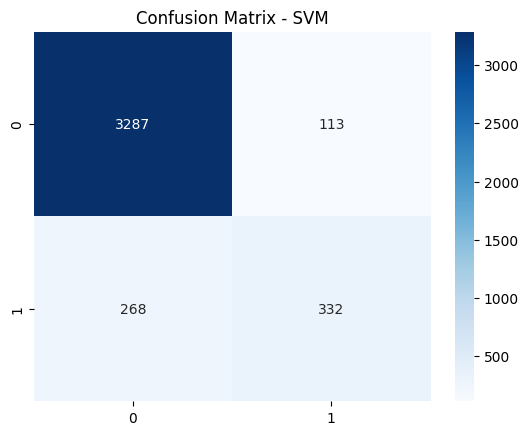

In [67]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ===================== Logistic Regression =====================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

evaluate_and_print("Logistic Regression", "Word2Vec", y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ===================== SVM =====================
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

evaluate_and_print("SVM", "Word2Vec", y_test, y_pred_svm)
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.show()